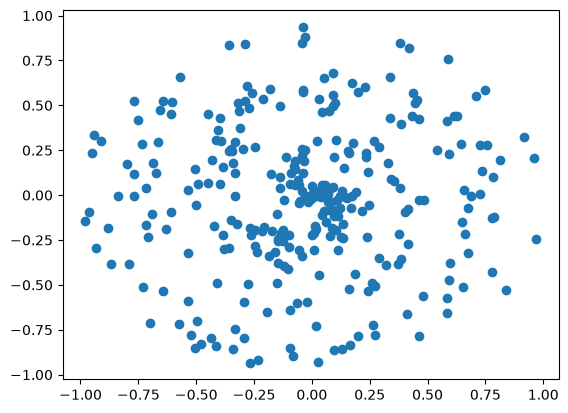

In [55]:
from nnfs.datasets import spiral_data
import numpy as np
import nnfs
nnfs.init()
import matplotlib.pyplot as plt
X,y = spiral_data(samples = 100,classes=3)
plt.scatter(X[:,0],X[:,1])
plt.show()

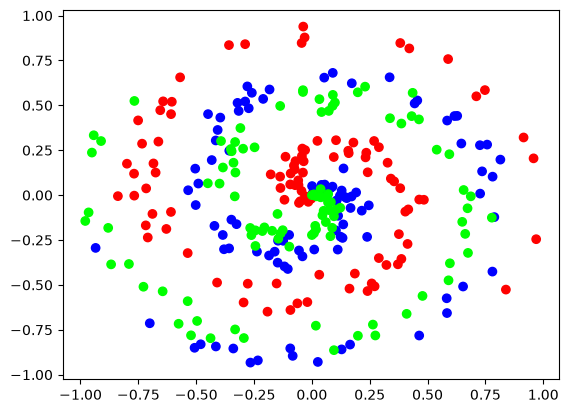

In [56]:
plt.scatter(X[:,0],X[:,1],c=y,cmap="brg")
plt.show()

In [57]:
class Layer_Dense:
    def __init__(self,n_inputs,n_neurons):

        self.weights =0.01*np.random.randn(n_inputs,n_neurons) # this is the transposed version of the w matrix remember that...
        self.biases = np.zeros((1,n_neurons))
    def forward(self,inputs):
        self.output = np.dot(inputs,self.weights) + self.biases

X,y = spiral_data(samples=100,classes = 3)

dense1 = Layer_Dense(2,3)
dense1.forward(X)
dense2=Layer_Dense(3,10)
dense2.forward(dense1.output)

# print(dense2.output[:5])


# dense1.output


## Activation functions

### ReLU

In [58]:
import numpy as np
inputs = [0,2,-1,3.3,-2.7,1.1,2.2,-100]
output = np.maximum(0,inputs)

In [59]:
class Activation_ReLU:
    def forward(self,inputs):
        self.output = np.maximum(0,inputs) 

In [60]:
X,y = spiral_data(samples=100,classes=3)
dense1 = Layer_Dense(2,3)
dense1.forward(X)
activation1 = Activation_ReLU()
activation1.forward(dense1.output)

print(activation1.output[:5])

[[0.0000000e+00 0.0000000e+00 0.0000000e+00]
 [0.0000000e+00 7.4274081e-05 1.0969164e-04]
 [0.0000000e+00 2.5570381e-04 1.2259498e-04]
 [0.0000000e+00 4.8552279e-04 1.8291285e-05]
 [0.0000000e+00 3.7701402e-04 3.7854823e-04]]


### Softmax activation function

In [61]:
inputs = [[1,2,3,2.5],
     [2,5,-1,2],
     [-1.5,2.7,3.3,-0.8]]
exp_values = np.exp(inputs-np.max(inputs,axis=1,keepdims = True))
probabilities = exp_values/np.sum(exp_values,axis=1,keepdims=True)
print(probabilities)

[[0.06414769 0.17437149 0.47399085 0.28748998]
 [0.04517666 0.90739747 0.00224921 0.04517666]
 [0.00522984 0.34875873 0.63547983 0.0105316 ]]


In [62]:
class Activation_Softmax:
    def forward(self,inputs):
        exp_values = np.exp(inputs-np.max(inputs,axis=1,keepdims = True))
        probabilities = exp_values/np.sum(exp_values,axis=1,keepdims=True)
        self.output = probabilities

In [63]:
# dense1 = Layer_Dense(2,3)
# dense1.forward(X)
# ReLU_dense1 =  Activation_ReLU()
# ReLU_dense1.forward(dense1.output)

# dense2 = Layer_Dense(3,3)
# dense2.forward(ReLU_dense1.output)
# Softmax_dense2 = Activation_Softmax()
# Softmax_dense2.forward(dense2.output)
# print(Softmax_dense2.output[:5])


## Forward Pass without loss function

### making a forward pass for this neural network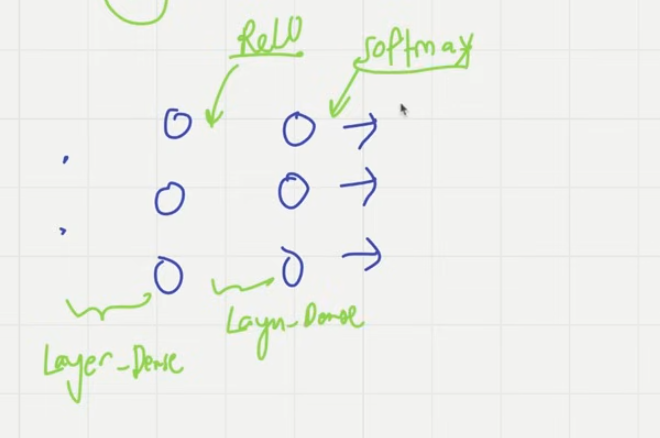

In [64]:
dense1 = Layer_Dense(2,3)
activation1 = Activation_ReLU()
dense2 = Layer_Dense(3,3)
activation2 = Activation_Softmax()

dense1.forward(X)
activation1.forward(dense1.output)
dense2.forward(activation1.output)
activation2.forward(dense2.output)

activation2.output

array([[0.33333334, 0.33333334, 0.33333334],
       [0.33333334, 0.3333335 , 0.33333316],
       [0.33333334, 0.33333433, 0.3333323 ],
       [0.3333333 , 0.3333356 , 0.3333311 ],
       [0.3333334 , 0.33333445, 0.3333321 ],
       [0.3333332 , 0.3333376 , 0.3333292 ],
       [0.3333332 , 0.3333383 , 0.33332855],
       [0.33333355, 0.3333344 , 0.33333212],
       [0.33333355, 0.33333445, 0.333332  ],
       [0.3333333 , 0.33333883, 0.33332786],
       [0.33333293, 0.33334267, 0.3333244 ],
       [0.3333331 , 0.33334216, 0.33332473],
       [0.3333332 , 0.3333419 , 0.3333249 ],
       [0.33333254, 0.3333432 , 0.33332425],
       [0.33333275, 0.33334637, 0.3333209 ],
       [0.3333336 , 0.33333755, 0.3333288 ],
       [0.3333325 , 0.3333476 , 0.3333199 ],
       [0.3333324 , 0.3333472 , 0.33332044],
       [0.3333323 , 0.3333484 , 0.33331928],
       [0.33333218, 0.3333472 , 0.33332068],
       [0.33333218, 0.3333496 , 0.33331826],
       [0.3333325 , 0.3333528 , 0.3333147 ],
       [0.

## Coding loss function

### Cross entropy loss building blocks in python 

In [65]:
softmax_outputs = np.array([[0.7,0.1,0.2],
                            [0.1,0.5,0.4],
                            [0.02,0.9,0.08]])
class_target = [0,1,1]
print(softmax_outputs[[0,1,2],class_target])
# print(softmax_outputs[range(len(softmax_outputs)),class_target]) # can also be written like this 

[0.7 0.5 0.9]


In [66]:
print(-np.log(softmax_outputs[range(len(softmax_outputs)),class_target]))
neg_log= -np.log(softmax_outputs[range(len(softmax_outputs)),class_target])
average_loss = np.mean(neg_log)
print(average_loss)

[0.35667494 0.69314718 0.10536052]
0.38506088005216804


### Extracting relavent prediction in one hot encoding 

In [67]:
y_true_check = np.array([
    [1,0,0],
    [0,1,0],
    [0,1,0]
])
y_pred_clipped_check =np.array([[0.7,0.2,0.1],
                            [0.1,0.5,0.4],
                            [0.02,0.9,0.08]])
softmax_outputs = (y_true_check*y_pred_clipped_check).sum(axis=1)
neg_log = -np.log(softmax_outputs)
print(np.mean(neg_log))
# softmax_outputs

0.38506088005216804


### Implementing loss class and Implementing Categorical Cross Entropy class

In [68]:
class Loss:
    def calculate(self,output,y):
        sample_losses = self.forward(output,y)
        data_loss=np.mean(sample_losses)
        return data_loss

In [69]:
class Loss_CategoricalEntropy(Loss):
    def forward(self,y_pred,y_true):
        samples = len(y_pred)

        y_pred_clipped = np.clip(y_pred,1e-7,1-1e-7)

        if len(y_true.shape) == 1:
            correct_confidences = y_pred_clipped[range(samples) , y_true]
        elif len(y_true.shape) == 2:
            correct_confidences = np.sum(y_pred_clipped*y_true,axis=1)

        negative_log_likelihoods = -np.log(correct_confidences)
        return negative_log_likelihoods
            

In [70]:
softmax_outputs = np.array([[0.7,0.1,0.2],
                            [0.1,0.5,0.4],
                            [0.02,0.9,0.08]])
class_targets = np.array([
    [1,0,0],
    [0,1,0],
    [0,1,0]
])

loss_function = Loss_CategoricalEntropy()
loss = loss_function.calculate(softmax_outputs,class_targets)
print(loss)

0.38506088005216804


In [71]:
X,y = spiral_data(samples = 100,classes=3)
dense1 = Layer_Dense(2,3)
activation1 = Activation_ReLU()
dense2 = Layer_Dense(3,3)
activation2 = Activation_Softmax()
loss_function = Loss_CategoricalEntropy()

dense1.forward(X)
activation1.forward(dense1.output)

dense2.forward(activation1.output)
activation2.forward(dense2.output)

loss = loss_function.calculate(activation2.output,y)
print("loss:",loss)

predictions = np.argmax(activation2.output,axis=1)
if len(y.shape) == 2:
    y = np.argmax(y,axis=1)
accuracy =np.mean(predictions == y)
accuracy


loss: 1.0986203


np.float64(0.3233333333333333)

In [72]:
softmax_outputs = np.array([[0.7,0.2,0.1],
                            [0.1,0.5,0.4],
                            [0.02,0.9,0.08]])
class_targets = np.array([0,1,1])

predictions = np.argmax(softmax_outputs,axis=1)

if len(class_targets.shape) == 2:
    class_targets = np.argmax(class_targets , axis=1)

accuracy=np.mean(predictions == class_targets)
accuracy

np.float64(1.0)

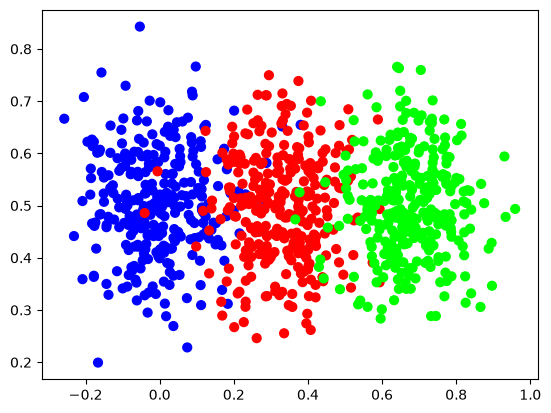

In [76]:
from nnfs.datasets import vertical_data
X,y = vertical_data(samples=300,classes=3)
plt.scatter(X[:,0],X[:,1],c=y,s=40,cmap="brg")

In [96]:
dense1 = Layer_Dense(2,3)
activation1 = Activation_ReLU()
dense2 = Layer_Dense(3,3)
activation2 = Activation_Softmax()
loss_function = Loss_CategoricalEntropy()

lowest_loss = 9999999
best_dense1_weights = dense1.weights.copy()
best_dense1_biases = dense1.biases.copy()
best_dense2_weights = dense2.weights.copy()
best_dense2_biases = dense2.biases.copy()

for iteration in range(100000):
    dense1.weights = 0.05 * np.random.randn(2,3)
    dense1.biases= 0.05 * np.random.randn(1,3)
    dense2.weights = 0.05 * np.random.randn(3,3)
    dense2.biases = 0.05 * np.random.randn(1,3)

    dense1.forward(X)
    activation1.forward(dense1.output)
    dense2.forward(activation1.output)
    activation2.forward(dense2.output)

    loss = loss_function.calculate(activation2.output,y)

    predictions = np.argmax(activation2.output,axis=1)
    accuracy = np.mean(predictions == y)

    if loss < lowest_loss:
        print("New set of weights found, iteration:",iteration,"loss:",loss,"acc:",accuracy)
        best_dense1_weights = dense1.weights.copy()
        best_dense1_biases = dense1.biases.copy()
        best_dense2_weights = dense2.weights.copy()
        best_dense2_biases = dense2.biases.copy()
        lowest_loss = loss

New set of weights found, iteration: 0 loss: 1.0992281 acc: 0.31777777777777777
New set of weights found, iteration: 1 loss: 1.0987453 acc: 0.3333333333333333
New set of weights found, iteration: 4 loss: 1.0981922 acc: 0.3333333333333333
New set of weights found, iteration: 34 loss: 1.0974852 acc: 0.3333333333333333
New set of weights found, iteration: 193 loss: 1.097372 acc: 0.3333333333333333
New set of weights found, iteration: 404 loss: 1.0972376 acc: 0.3333333333333333
New set of weights found, iteration: 1182 loss: 1.0971313 acc: 0.4533333333333333
New set of weights found, iteration: 1561 loss: 1.096911 acc: 0.3333333333333333
New set of weights found, iteration: 4450 loss: 1.0967683 acc: 0.3333333333333333
New set of weights found, iteration: 4669 loss: 1.0963157 acc: 0.3477777777777778
New set of weights found, iteration: 11279 loss: 1.0949955 acc: 0.3333333333333333
New set of weights found, iteration: 61129 loss: 1.094851 acc: 0.5355555555555556
New set of weights found, ite

KeyboardInterrupt: 